<a href="https://colab.research.google.com/github/Rogire/Aulas-MAC019/blob/main/Atividade01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Alunos:
- Igor Correa Trifilio Campos - 202365092AB
- Davi Luís de Faria Rocha - 202365519B


## Instalação de dependências

In [ ]:
# instalação do anastruct
!pip install anastruct

# importando os pacotes
import numpy as np
import matplotlib.pyplot as plt
from anastruct import SystemElements
from collections import defaultdict
from dataclasses import dataclass, field
import pandas as pd
from typing import List, Dict, Optional, Tuple, Any

## Classe para facilitar a manipulação do anastruct: Componentes auxiliares


In [ ]:
@dataclass
class point_load:
    node: str
    load_vec: Tuple[float, float, float]
    rotation: float = 0.0
    node_id_cache: Optional[int] = None

    def load(self, ss: SystemElements, node_id: Optional[int] = None):
        nid = node_id if node_id is not None else self.node_id_cache
        if nid is None:
            raise ValueError("node_id não fornecido para PointLoad.apply")

        return ss.point_load(node_id=nid, Fx=self.load_vec[0], Fy=self.load_vec[1], Fz=self.load_vec[2], rotation=self.rotation)

@dataclass
class charge_load:
    q: float
    element_id: int
    direction: str

    def load(self, ss: SystemElements):
        return ss.q_load(q=self.q, element_id=self.element_id, direction=self.direction)

@dataclass
class node:
    pos: List[float]
    conecs: List[Dict[str, Any]] = field(default_factory=list)  # each: {"con": name, "d": diam}
    support: str = ""
    ss_id: Optional[int] = None

    def get_pos(self) -> List[float]:
        return self.pos

    def get_conecs(self) -> List[Dict[str, Any]]:
        return self.conecs

    def get_support_type(self) -> str:
        return self.support
    def id(self, ss: SystemElements) -> int:
        nid = ss.find_node_id(self.pos)
        if nid is None:
            for node_idx, n_obj in ss.node_map.items():
                if np.allclose(n_obj.post, self.pos, atol=1e-3):
                    return node_idx
        return nid

    def get_support(self, ss: SystemElements):
        if not self.support:
            return

        nid = self.id(ss)
        if nid is None: return

        if self.support == "1x":
            # Se Ry=0 e Rx=1: trava X, rola em Y
            ss.add_support_roll(nid, direction="y")
        elif self.support == "1y":
            # Se Ry=1 e Rx=0: trava Y, rola em X (CASO DO SEU NÓ H)
            ss.add_support_roll(nid, direction="x")
        elif self.support == "2":
            ss.add_support_hinged(nid)
        elif self.support == "3":
            ss.add_support_fixed(nid)

class Aux:
    @staticmethod
    def leitura_data(sheet_id:str):
        get_sheet = lambda data_name : f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={data_name}"
        return (
                pd.read_csv(get_sheet("Nos")),
                pd.read_csv(get_sheet("Barras")),
                pd.read_csv(get_sheet("Cargas")),
                pd.read_csv(get_sheet("Apoios"))
            )

    @staticmethod
    def set_dicts(n : int):
        return (defaultdict(list) for _ in range(n))

    @staticmethod
    def calc_height(CA: float,theta_deg:float)->float:
      theta = np.deg2rad(theta_deg)
      return np.tan(theta)*CA

    @staticmethod
    def calc_d(sigma_adm: float, Nmax: float) -> float:
        return np.sqrt(np.abs((4*Nmax)/(sigma_adm*np.pi)))

    @staticmethod
    def calc_mass(rho: float, d: float, L: float, return_weight: bool = False) -> float:
        A = np.pi * (d ** 2) / 4.0
        massa = rho * A * L

        if return_weight:
            return massa * 9.81

        return massa

    @staticmethod
    def translate_ap(apoios):
        if apoios == [1,1,0]: # Fixo (Rx=1, Ry=1)
            return "2"
        if apoios == [1,0,0]: # Rolete que trava X (Rx=1, Ry=0)
            return "1x"
        if apoios == [0,1,0]: # Rolete que trava Y (Rx=0, Ry=1) -> CASO DO NÓ H
            return "1y"
        if apoios == [1,1,1]: # Engastado
            return "3"


## Classe para facilitar a manipulação do anastruct: Montagem da estrutura

In [ ]:
class Estrutura:
    def __init__(self, nodes: Optional[Dict[str, node]] = None,
                 loads: Optional[List[point_load]] = None,
                 sheet_id: Optional[str] = None,
                 theta_str: Optional[float] = None,
                 E: Optional[float] = None):

        self.nodes: Dict[str, node] = {} if nodes is None else nodes
        self.sheet_id = sheet_id
        self.loads: Optional[List[point_load]] = loads
        self.theta_str = theta_str
        self.E = E
        self.elements = {}
        self.ss = SystemElements()

        if self.sheet_id is not None:
            if len(self.nodes) > 0 or self.loads is not None: raise Exception("Ou se lê a estrutura pela planilha, ou a estrutura vai por parâmetro.")
            self.init_from_sheet()

        self.init_elements()


    def reset_struct(self,vef=False):
        print("Criando estrutura com E= " + str(self.E))

        self.ss = SystemElements()

        if vef and self.sheet_id is not None:
            if self.nodes:
                raise Exception("Ou se lê a estrutura pela planilha, ou a estrutura vai por parâmetro.")
            self.init_from_sheet()

        self.init_elements()

    def init_elements(self):
            #cria todas as barras primeiro
            for key, n_obj in self.nodes.items():
                for c in n_obj.get_conecs():
                    connection = c["con"]
                    # Se d for None (planilha vazia), assume 20mm para ter rigidez
                    diameter = c["d"] if (c["d"] is not None and not np.isnan(c["d"])) else 20.0

                    d_m = float(diameter) / 1000.0
                    area_m2 = np.pi * (d_m ** 2) / 4.0
                    eid = self.ss.add_truss_element(
                        location=[n_obj.pos, self.nodes[connection].pos],
                        EA=self.E * area_m2
                    )
                    #Mapeia o elemento para cálculos posteriores
                    self.elements[str(key) + str(connection)] = {
                        "id": eid,
                        "d": diameter
                    }

            #Aplica os apoios
            for n_obj in self.nodes.values():
                n_obj.get_support(self.ss)

            #Aplica as cargas
            if self.loads is not None:
                for l in self.loads:
                    target_node = self.nodes.get(l.node)
                    if target_node:
                        l.load(self.ss, target_node.id(self.ss))

    def init_from_sheet(self):
      nos, barras, cargas, apoios = Aux.leitura_data(self.sheet_id)
      nodes_pos, nodes_conecs, nodes_carg, nodes_ap = Aux.set_dicts(4)

      #monta pos
      for i in range(nos.shape[0]):
        pos_x, pos_y = nos["x"][i], nos["y"][i]

        if np.isnan(pos_y):
          pos_y = Aux.calc_height(3, self.theta_str)
        else:
          pos_y = float(pos_y)

        nodes_pos[nos["Nome"][i]] = [pos_x,pos_y]
        nodes_conecs[nos["Nome"][i]] = []
        nodes_ap[nos["Nome"][i]] = ""

      #monta conecs
      for i in range(barras.shape[0]):
        if "diametro" in barras.columns:
            diametro = barras["diametro"][i]
        else:
            diametro = 20.0 # Valor padrão caso a coluna não exista na planilha

        nodes_conecs[barras["Nó inicial"][i]].append({"con":barras["Nó final"][i], "d":diametro})

      for i in range(cargas.shape[0]):
        nodes_carg[cargas["Nó"][i]] = [cargas["Fx"][i],cargas["Fy"][i],0]

      for i in range(apoios.shape[0]):
        nodes_ap[apoios["Nó"][i]] = Aux.translate_ap([apoios["Rx"][i],apoios["Ry"][i],apoios["M"][i]])

      for key in nodes_pos:
        self.nodes[key] = node(nodes_pos[key], nodes_conecs[key], nodes_ap[key])

      self.loads = [point_load(i,nodes_carg[i]) for i in nodes_carg]

    def selec_Nmax_el(self):
        # resolve e mapeia resultados por id para acesso O(1)
        self.ss.solve()
        results = self.ss.get_element_results()
        results_map = {int(r["id"]): r for r in results}

        # preencher elementos com Ni e length
        for pair, meta in self.elements.items():
            eid = int(meta["id"])
            res = results_map.get(eid)
            if res:
                meta["Ni"] = res.get("Nmax")
                meta["length"] = res.get("length")

    def recalculate_struct(self,sigma=140,rho=7800):
        if self.theta_str is None:
            return

        self.selec_Nmax_el()
        node_keys = list(self.nodes.keys())

        for i in range(len(node_keys)):
            node = node_keys[i]
            prox = (i+1) if (i+1) < len(node_keys) else i
            at = i if (i+1) < len(node_keys) else i-1

            if self.nodes[node].pos[1] == 0:
                pos_y = 0
            else:
                pos_y = Aux.calc_height(3, self.theta_str)

            self.nodes[node].pos[1] = pos_y

            for j in self.nodes[node].conecs:
                bar = str(node)+j["con"]
                diam = Aux.calc_d(sigma,self.elements[bar]["Ni"])
                j["d"] = diam
                self.elements[bar]["d"] = diam

        self.reset_struct()
        self.selec_Nmax_el()
        self.show_mass(rho)
        self.ss.show_structure()

    def rec_theta(self,rho=7800):
        if self.theta_str is None:
            raise ValueError("theta_str não inicializado")

        while self.theta_str <= 80:
            print(f"Theta: {self.theta_str}")
            self.recalculate_struct(rho=rho)
            self.theta_str += 5

    def print_nodes(self):
        for i in self.nodes:
            print(i + ": " + str(self.nodes[i].get_pos())+", "+str(self.nodes[i].get_conecs())+", "+str(self.nodes[i].get_support_type()))

    def show(self):
      self.ss.show_structure()

    def show_mass(self, rho: float):
        mass = 0.0
        for pair, value in self.elements.items():
            d = value.get("d")
            L = value.get("length")
            if d is None or L is None:
                continue
            mass += Aux.calc_mass(rho, d, L)

        print("Massa da estrutura: ",mass)

    def solve_sys(self):
        print("Estrutura modelada:")
        self.ss.show_structure()
        print("Plots Estrutura:")
        self.ss.solve()
        print("Reação de apoios:")
        self.ss.show_reaction_force()
        print("Reação axial:")
        self.ss.show_axial_force()
        print("Deslocamentos:")
        self.ss.show_displacement()

        print("\nDeslocamentos por nó (mm):")
        for key, i in self.nodes.items():
            disp = self.ss.get_node_displacements(i.id(self.ss))

            ux = float(disp["ux"]) * 1000  # m → mm
            uy = float(disp["uy"]) * 1000

            print(f"Nó {key}: ux = {ux:.4f} mm | uy = {uy:.4f} mm")

        print("\nEsforços nas barras:")
        for key, value in self.elements.items():
            N = float(self.ss.get_element_results(int(value["id"]))["Nmax"])

            # limpar erro numérico
            if abs(N) < 1e-6:
                N = 0

            tipo = "Tração" if N > 0 else "Compressão" if N < 0 else "Nulo"

            print(f"Barra {key}: {abs(N):.2f} N ({tipo})")





## Exercício 01
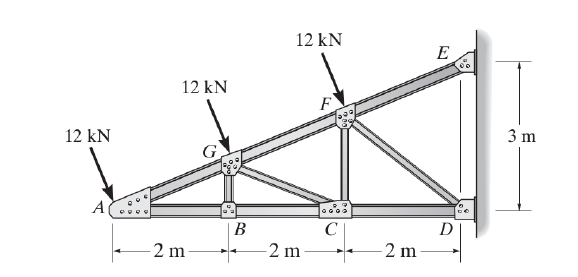


- Módulo de elasticidade: 210GPa
- Diâmetro barras AE,AD: 20mm
- DIâmetro demais barras: 10mm

###Alternativa a)
*A treliça é isostática? Justifique.*

Sim. A treliça possui dois apoios de segundo gênero, nos pontos D e E, e cada um fornece 2 reações de apoio (totalizando 4). Além disso, existem 10 barras, cada uma fornecendo um esforço interno. No total, temos 14 incógnitas.
Cada nó possibilita duas equações: somatório de forças em x e y iguais a zero. Temos 7 nós, portanto, 14 equações. O número de incógnitas é igual ao de equações, então, a treliça é isostática.

###Alternativas b) e c)

Estrutura modelada:


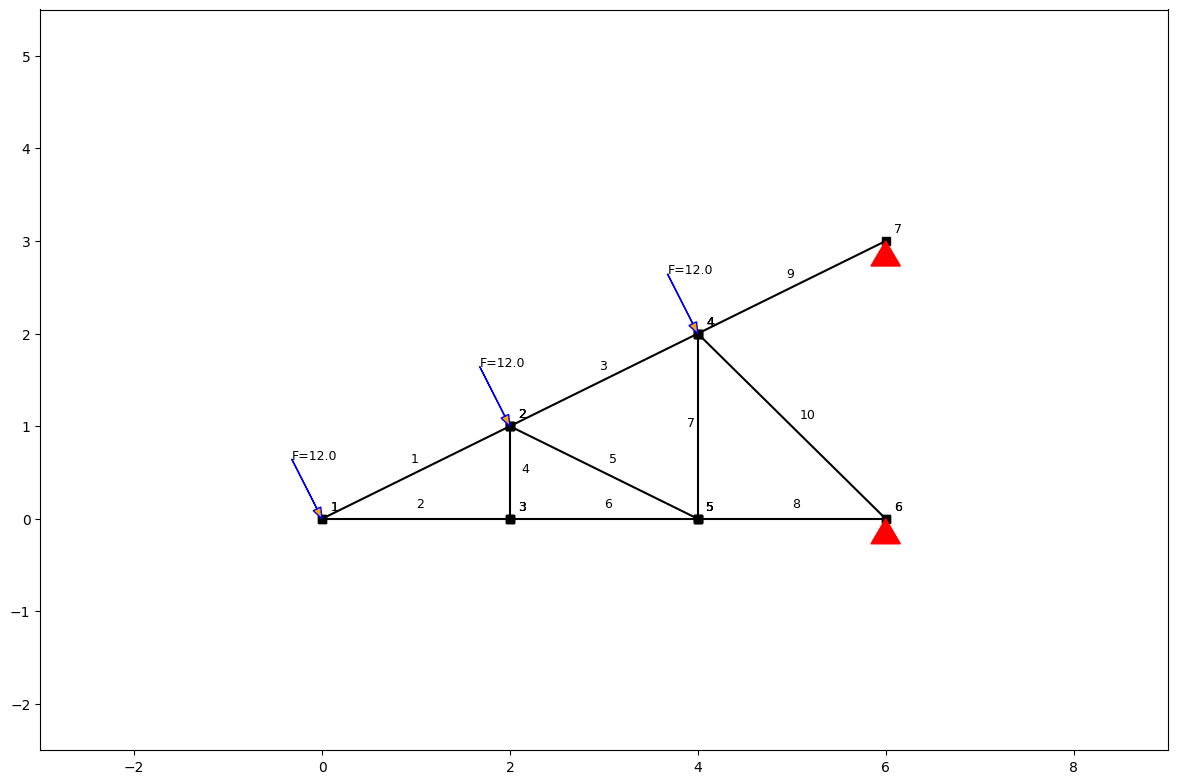

Plots Estrutura:
Reação de apoios:


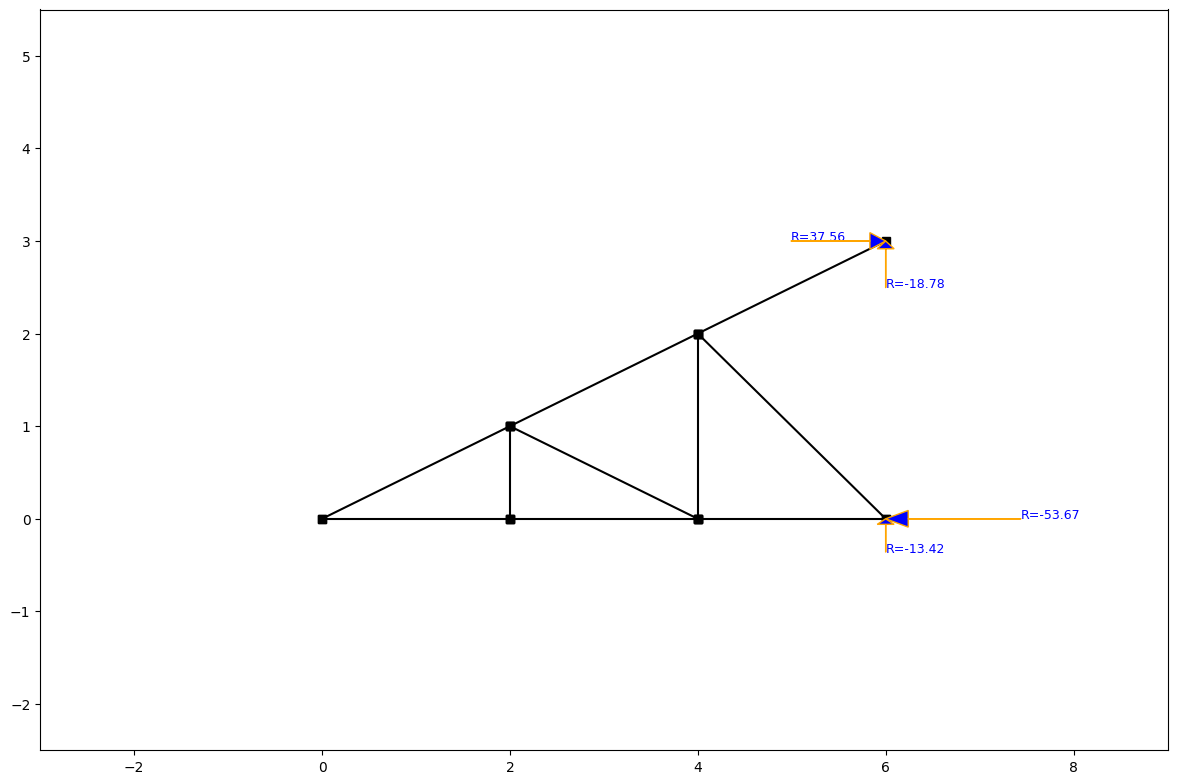

Reação axial:


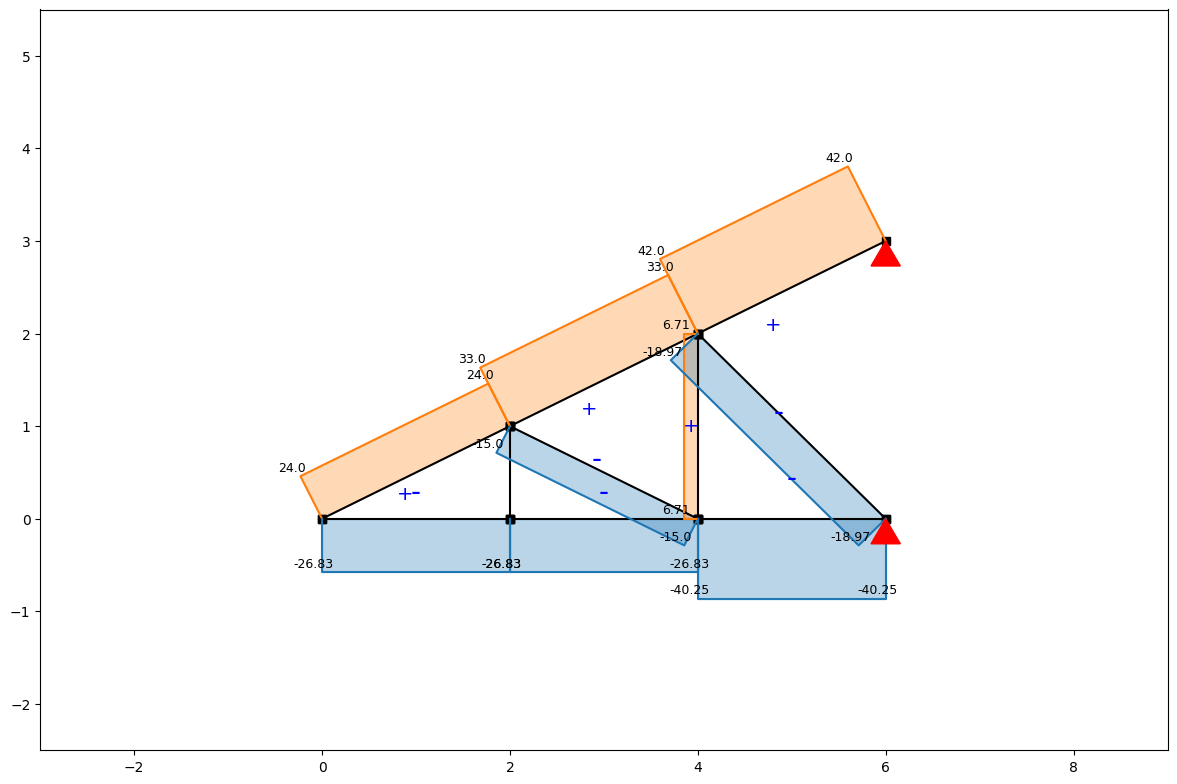

Deslocamentos:


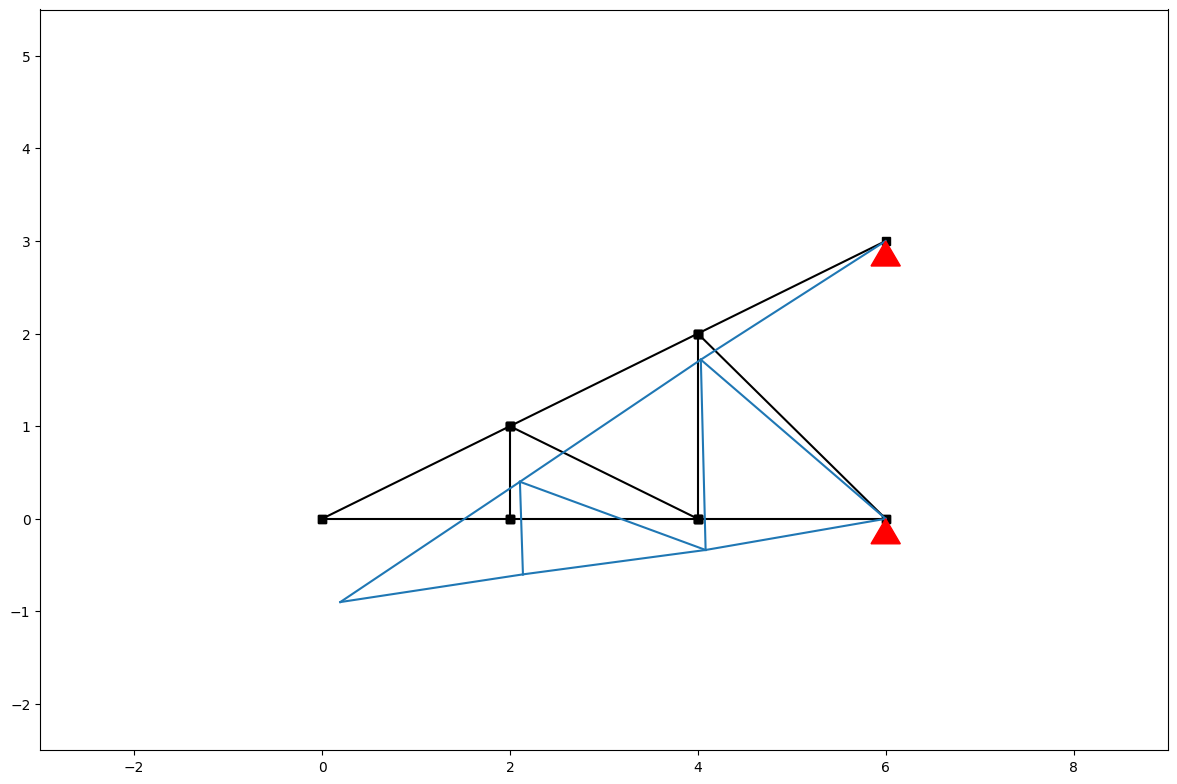


Deslocamentos por nó (mm):
Nó A: ux = 0.0028 mm | uy = -0.0132 mm
Nó G: ux = 0.0016 mm | uy = -0.0088 mm
Nó B: ux = 0.0020 mm | uy = -0.0088 mm
Nó C: ux = 0.0012 mm | uy = -0.0049 mm
Nó F: ux = 0.0005 mm | uy = -0.0041 mm
Nó E: ux = 0.0000 mm | uy = -0.0000 mm
Nó D: ux = 0.0000 mm | uy = -0.0000 mm

Esforços nas barras:
Barra AG: 24.00 N (Tração)
Barra AB: 26.83 N (Compressão)
Barra GF: 33.00 N (Tração)
Barra GB: 0.00 N (Nulo)
Barra GC: 15.00 N (Compressão)
Barra BC: 26.83 N (Compressão)
Barra CF: 6.71 N (Tração)
Barra CD: 40.25 N (Compressão)
Barra FE: 42.00 N (Tração)
Barra FD: 18.97 N (Compressão)


In [ ]:
nodes = {
        "A":node([0,0],[{"con":"G","d":20.0},{"con":"B","d":20.0}]),
        "G":node([2,1],[{"con":"F","d":20.0},{"con":"B","d":10.0},{"con":"C","d":10.0}]),
        "B":node([2,0],[{"con":"C","d":20.0}]),
        "C":node([4,0],[{"con":"F","d":10.0},{"con":"D","d":20.0}]),
        "F":node([4,2],[{"con":"E","d":20.0},{"con":"D","d":10.0}]),
        "E":node([6,3],[],"2"),
        "D":node([6,0],[],"2")
}
loads = [point_load("A",[12,0,0],63.43),
         point_load("G",[12,0,0],63.43),
         point_load("F",[12,0,0],63.43)]

teste2 = Estrutura(nodes,loads,theta_str=20,E=210e9)
teste2.solve_sys()

###Alternativa d)

Estrutura modelada:


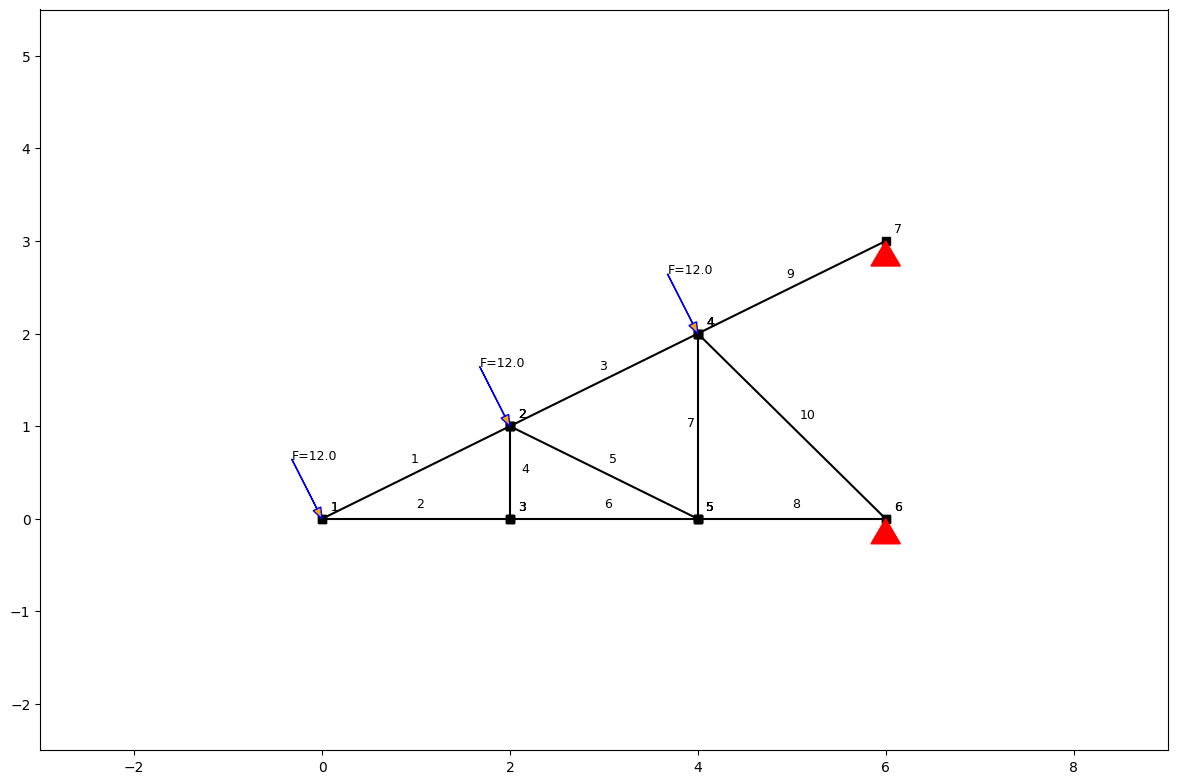

Plots Estrutura:
Reação de apoios:


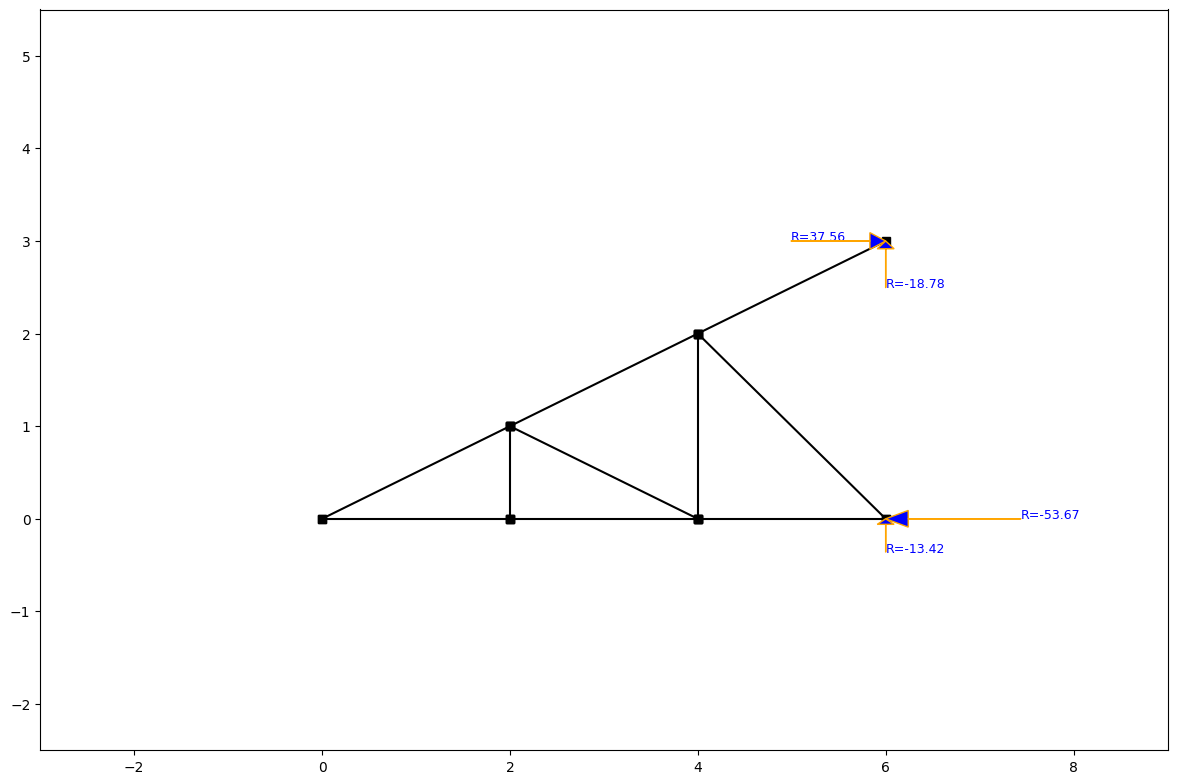

Reação axial:


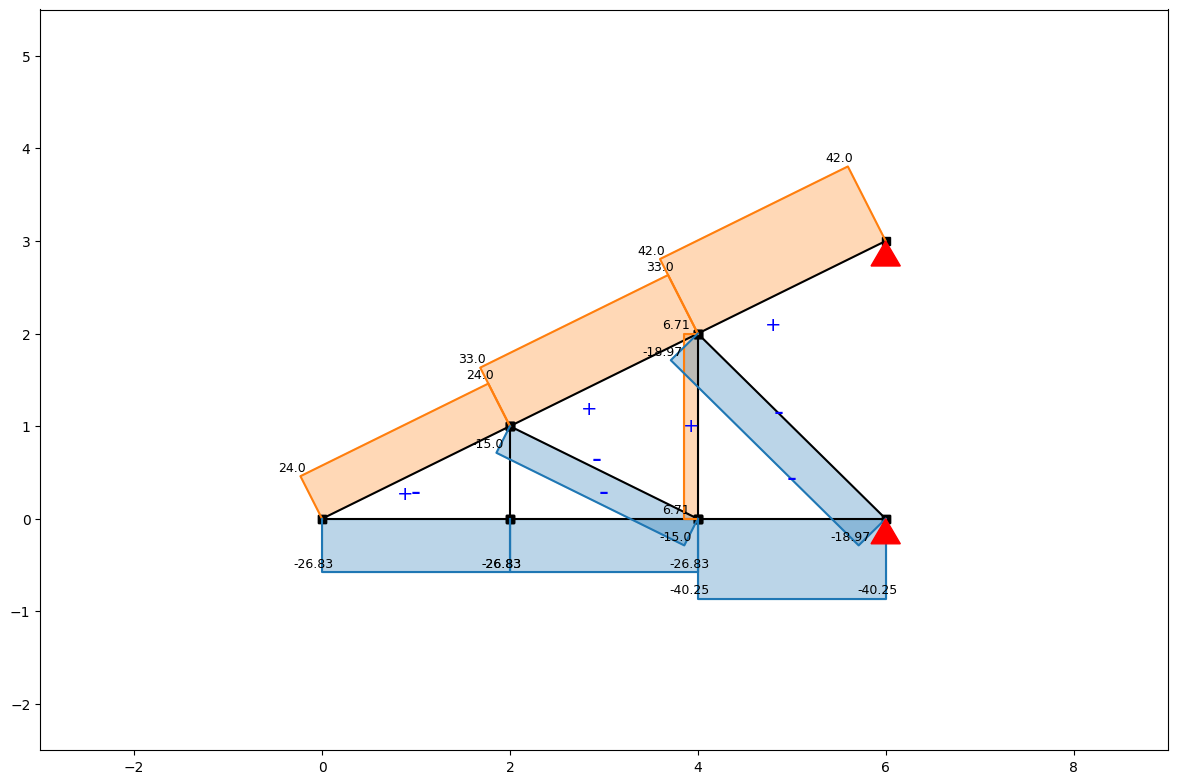

Deslocamentos:


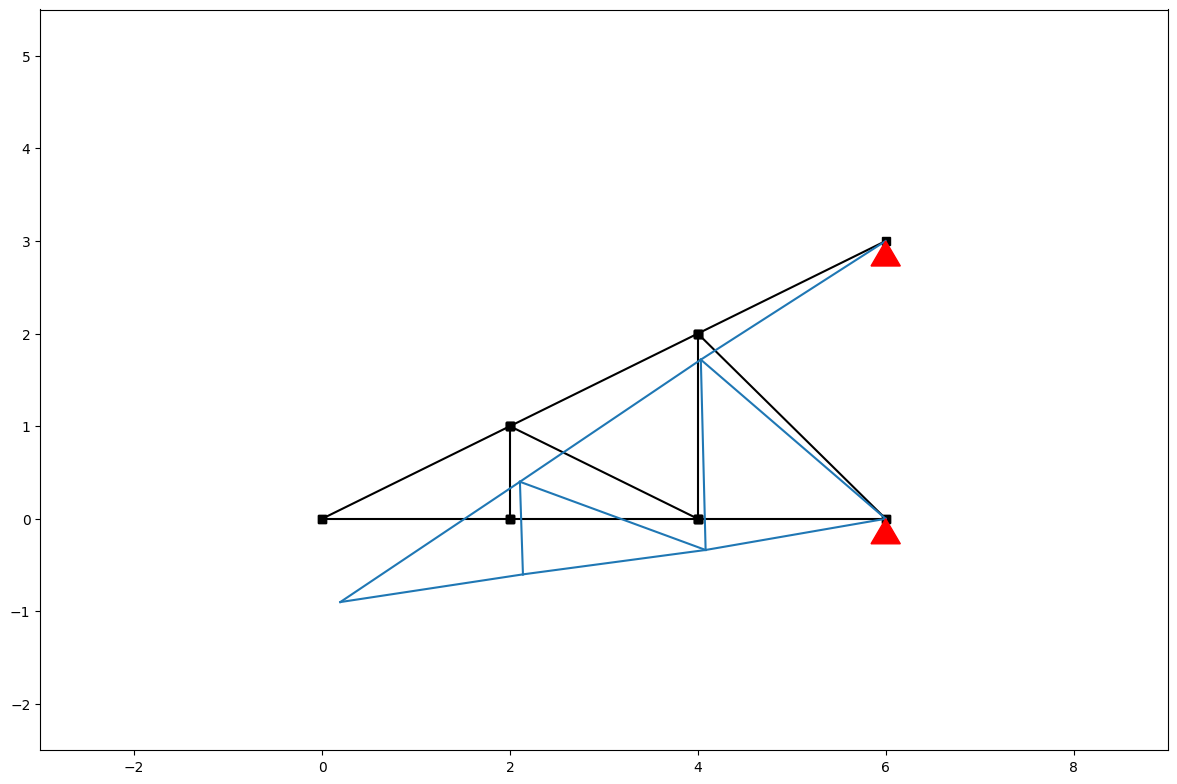


Deslocamentos por nó (mm):
Nó A: ux = 0.0085 mm | uy = -0.0396 mm
Nó G: ux = 0.0047 mm | uy = -0.0264 mm
Nó B: ux = 0.0061 mm | uy = -0.0264 mm
Nó C: ux = 0.0037 mm | uy = -0.0148 mm
Nó F: ux = 0.0014 mm | uy = -0.0124 mm
Nó E: ux = 0.0000 mm | uy = -0.0000 mm
Nó D: ux = 0.0000 mm | uy = -0.0000 mm

Esforços nas barras:
Barra AG: 24.00 N (Tração)
Barra AB: 26.83 N (Compressão)
Barra GF: 33.00 N (Tração)
Barra GB: 0.00 N (Nulo)
Barra GC: 15.00 N (Compressão)
Barra BC: 26.83 N (Compressão)
Barra CF: 6.71 N (Tração)
Barra CD: 40.25 N (Compressão)
Barra FE: 42.00 N (Tração)
Barra FD: 18.97 N (Compressão)


In [ ]:
nodes = {
        "A":node([0,0],[{"con":"G","d":20.0},{"con":"B","d":20.0}]),
        "G":node([2,1],[{"con":"F","d":20.0},{"con":"B","d":10.0},{"con":"C","d":10.0}]),
        "B":node([2,0],[{"con":"C","d":20.0}]),
        "C":node([4,0],[{"con":"F","d":10.0},{"con":"D","d":20.0}]),
        "F":node([4,2],[{"con":"E","d":20.0},{"con":"D","d":10.0}]),
        "E":node([6,3],[],"2"),
        "D":node([6,0],[],"2")
}
loads = [point_load("A",[12,0,0],63.43),
         point_load("G",[12,0,0],63.43),
         point_load("F",[12,0,0],63.43)]

teste2 = Estrutura(nodes,loads,theta_str=20,E=70e9,)
teste2.solve_sys()

Sim, os deslocamentos aumentaram em três vezes, como esperado, visto que as barras passaram a ser três vezes menos rígidas, permitindo maiores deslocamentos. Os esforços na barra não mudam, porque, numa treliça isostática, as forças dependem apenas das equações de equilíbrio, e não da rigidez.

## Exercício 2
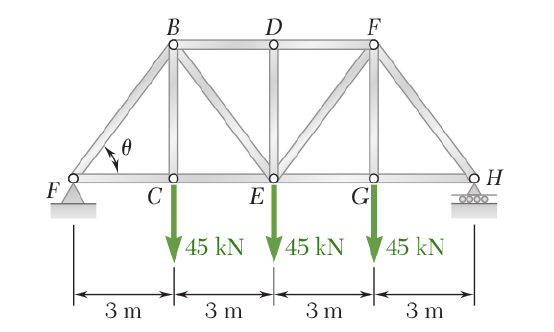

- $ σ_{max} = 140 \frac{N}{mm²}$
- Θ : 20º a 80º
- F = 45kN
- $ρ = 78000 \frac{N}{m³}$  

###Alternativa a)

In [ ]:
data_id_2 = '1jzy3kEZVjZMfUIvRuSjedZa4880eSaHbzu0TtHxsQ98'
theta = 20
resultados_a = []

while theta <= 80:
    # Cria a estrutura para o theta atual
    est = Estrutura(theta_str=theta, sheet_id=data_id_2, E=210e9)
    est.selec_Nmax_el()

    peso_total = 0
    for key, el in est.elements.items():
        N = abs(el.get("Ni", 0))
        L = el.get("length", 0)

        if N < 1e-3: continue # Ignora barras de força nula

        # Área = Força / Tensão Admissível (140 N/mm²)
        A = N / 140e6
        peso_total += 78000 * A * L # Peso = rho * A * L

    resultados_a.append((theta, peso_total))
    theta += 5

print("Resultados Letra A:")
for t, p in resultados_a:
    print(f"Theta: {t}° | Peso: {p:.2f} N")

Resultados Letra A:
Theta: 20° | Peso: 3057.35 N
Theta: 25° | Peso: 2468.60 N
Theta: 30° | Peso: 2084.40 N
Theta: 35° | Peso: 1819.83 N
Theta: 40° | Peso: 1633.59 N
Theta: 45° | Peso: 1504.29 N
Theta: 50° | Peso: 1421.39 N
Theta: 55° | Peso: 1381.82 N
Theta: 60° | Peso: 1389.60 N
Theta: 65° | Peso: 1458.81 N
Theta: 70° | Peso: 1623.16 N
Theta: 75° | Peso: 1966.37 N
Theta: 80° | Peso: 2745.04 N


###Alternativa b)

In [ ]:
# Pega o melhor resultado da letra A para saber por onde começar
melhor_t_a = min(resultados_a, key=lambda x: x[1])[0]

refinado = []
# Testa num intervalo de 5 graus ao redor do melhor da letra A
for t in range(melhor_t_a - 5, melhor_t_a + 6):
    est = Estrutura(theta_str=t, sheet_id=data_id_2, E=210e9)
    est.selec_Nmax_el()
    peso = sum([ (abs(e['Ni'])/140e6)*e['length']*78000 for e in est.elements.values() if abs(e.get('Ni',0)) > 1e-3 ])
    refinado.append((t, peso))

otimo = min(refinado, key=lambda x: x[1])
print(f"\nLetra B: O ângulo ótimo é {otimo[0]}° com peso de {otimo[1]:.2f} N")


Letra B: O ângulo ótimo é 57° com peso de 1378.75 N


###Alternativa c)
Nó A: Aplica uma carga puramente horizontal (20 kN para a esquerda).

Nó B: Aplica uma carga puramente vertical (45 kN para baixo).

Nó F: Aplica uma carga inclinada (resultante da combinação de 30 kN horizontal e -30 kN vertical).

Estrutura modelada:


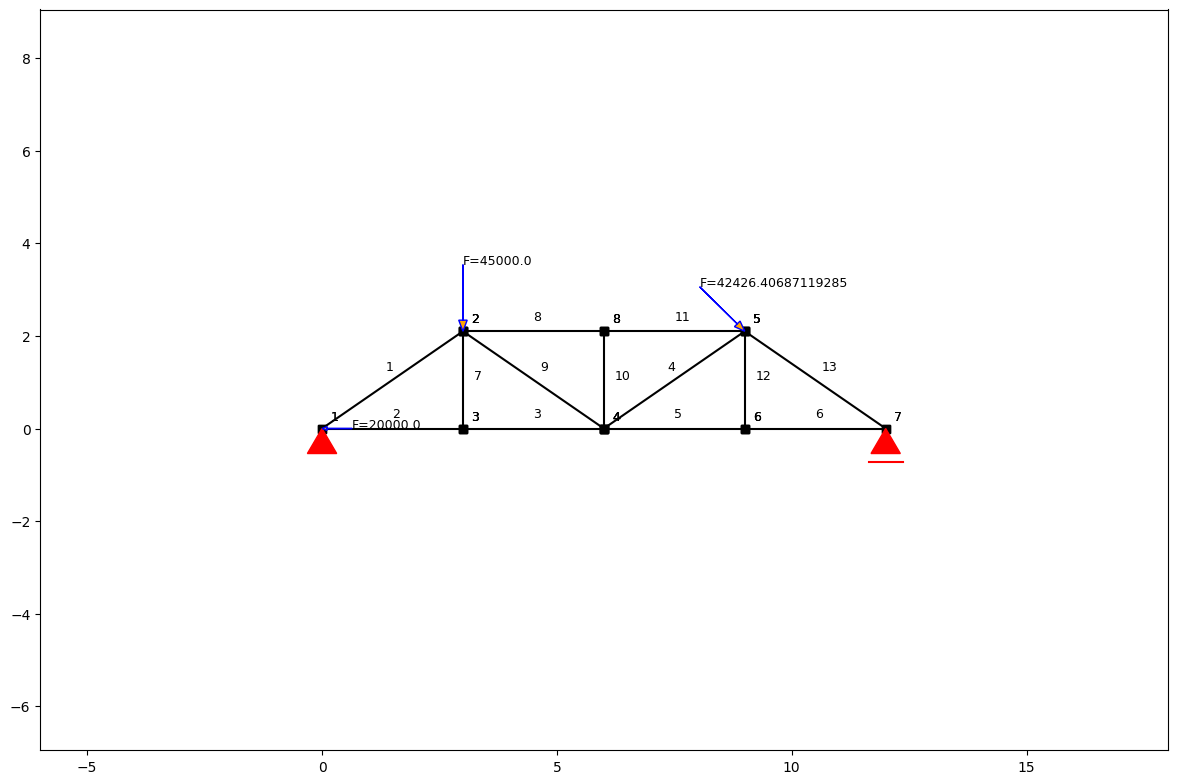

Plots Estrutura:
Reação de apoios:


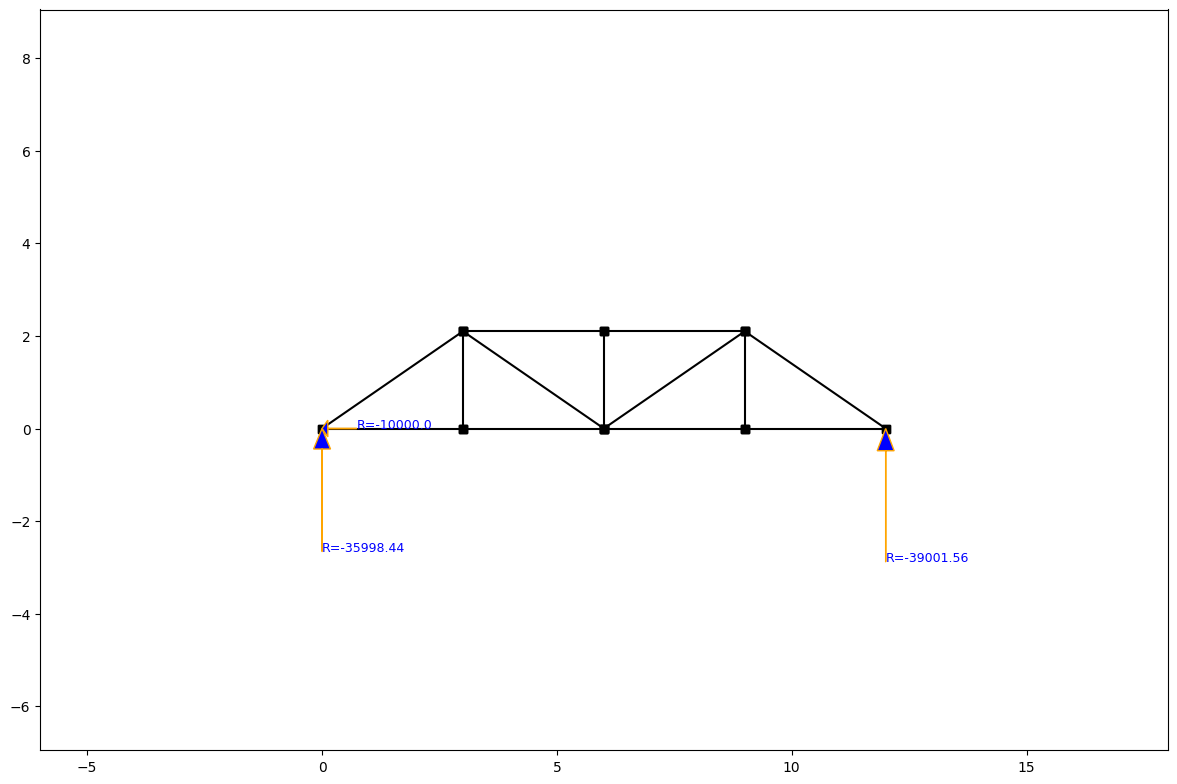

Reação axial:


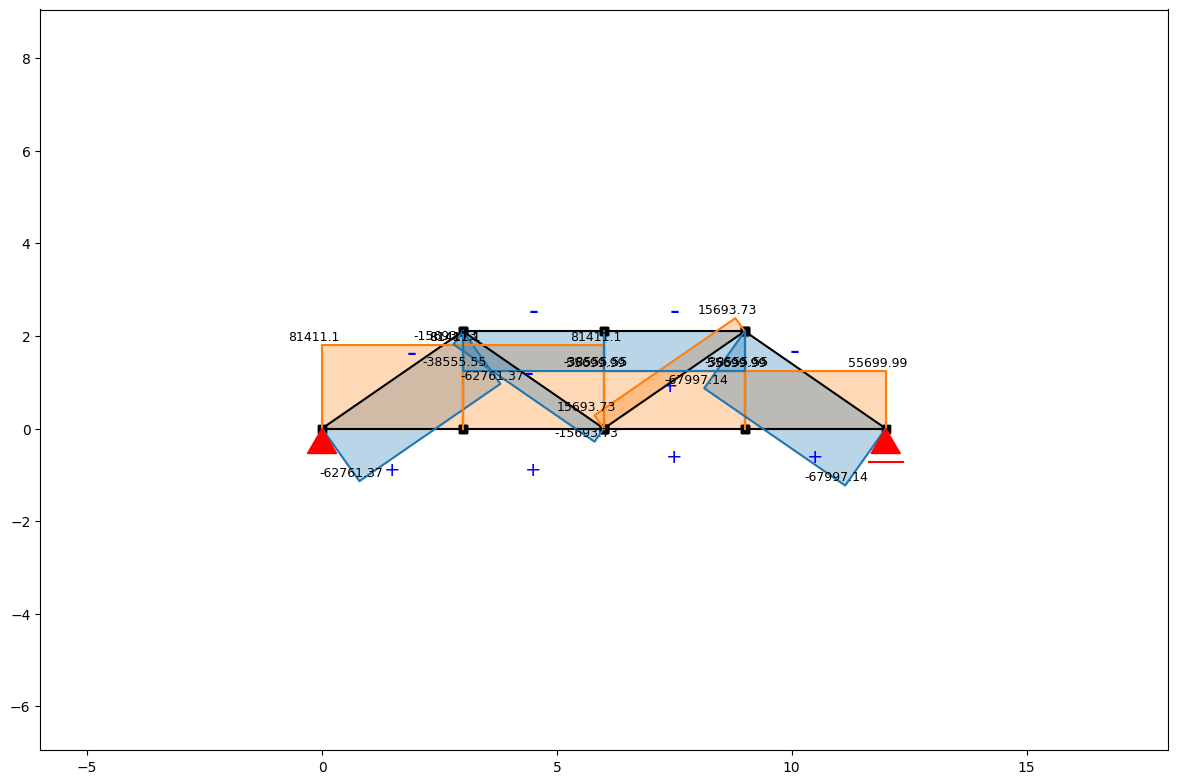

Deslocamentos:


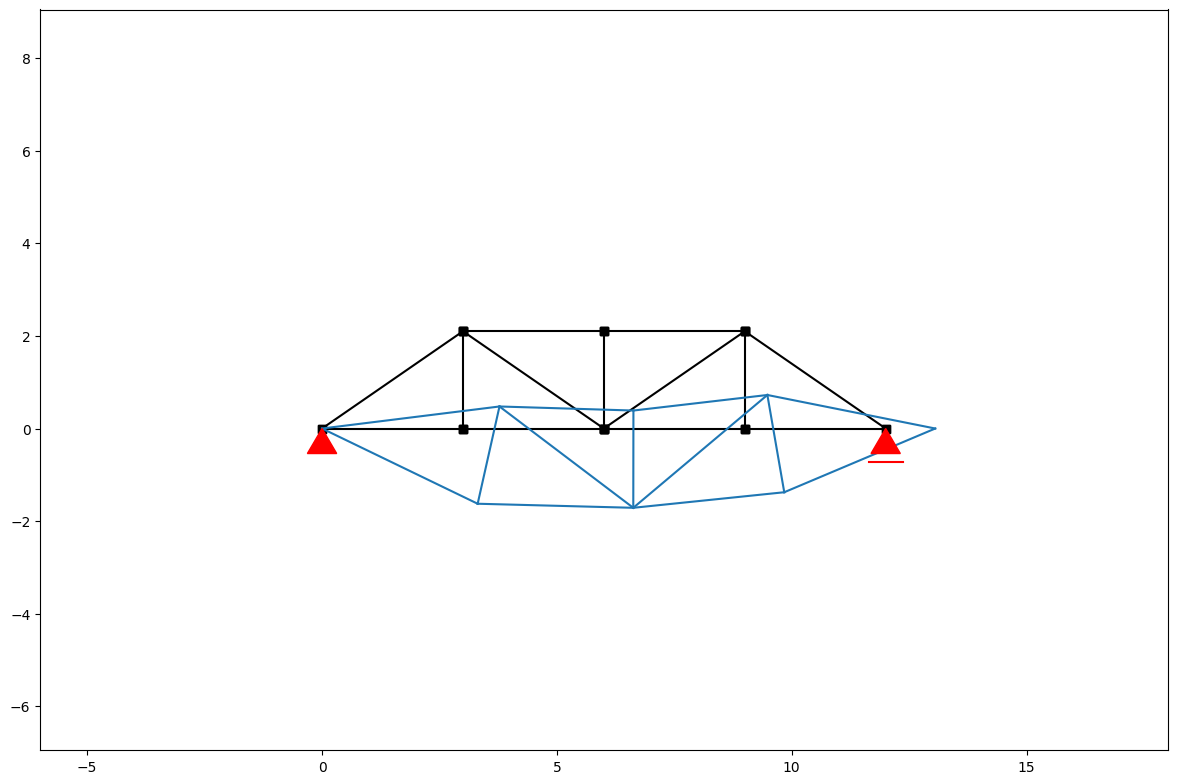


Deslocamentos por nó (mm):
Nó A: ux = 0.0000 mm | uy = -0.0000 mm
Nó C: ux = 3.7020 mm | uy = -19.2033 mm
Nó E: ux = 7.4040 mm | uy = -20.2396 mm
Nó G: ux = 9.9368 mm | uy = -16.2681 mm
Nó H: ux = 12.4697 mm | uy = -0.0000 mm
Nó B: ux = 9.1931 mm | uy = -19.2033 mm
Nó D: ux = 7.4399 mm | uy = -20.2396 mm
Nó F: ux = 5.6866 mm | uy = -16.2681 mm

Esforços nas barras:
Barra AB: 62761.37 N (Compressão)
Barra AC: 81411.10 N (Tração)
Barra CE: 81411.10 N (Tração)
Barra EF: 15693.73 N (Tração)
Barra EG: 55699.99 N (Tração)
Barra GH: 55699.99 N (Tração)
Barra BC: 0.00 N (Nulo)
Barra BD: 38555.55 N (Compressão)
Barra BE: 15693.73 N (Compressão)
Barra DE: 0.00 N (Nulo)
Barra DF: 38555.55 N (Compressão)
Barra FG: 0.00 N (Nulo)
Barra FH: 67997.14 N (Compressão)


In [ ]:
data_id_3 = '1Z5eCnY7BZszXvqSeDXVZqyQNp5d9bBDh5T6U1p3FCrM'
est_c = Estrutura(theta_str=35, sheet_id=data_id_3, E=210e9)
est_c.solve_sys()